In [1]:
import sys
sys.path.append("../scripts/")

In [2]:
import multiprocessing as mp
import warnings


import numpy as np
from scipy.stats import binned_statistic, binned_statistic_2d
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import matplotlib as mpl
from scipy.interpolate import interp1d
from scipy.signal import windows
from scipy import linalg
from nautilus import Prior, Sampler
import corner

In [3]:
Cs = sns.color_palette("colorblind")
Cp = sns.color_palette("Paired")

In [4]:
import niceplots
niceplots.initPlot()

In [5]:
from classy_wraper_for_m21cm import *
from specs import *
from meer21cm import PowerSpectrum
from meer21cm.power import get_modelpk_conv


# Compare model to simulations

In [6]:
z_func = interp1d(
    z_cen, z_count / dV_arr, kind="linear", bounds_error=False, fill_value=0
)

ps = PowerSpectrum(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        discrete_source_dndz=z_func,
        tracer_bias_2=1.5,
        tracer_bias_1=1.5,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
        sigma_beam_ch=sigma_beam_new,
        sigma_v_1= 100, # in velocity units
        sigma_v_2= 100,
    )

ps.grid_scheme = "cic"
ps.taper_function = getattr(windows, window_name)

num_gal = int(ps.survey_volume * n_gal)
ps.num_discrete_source = num_gal
ps.W_HI = np.ones_like(ps.W_HI)
ps.w_HI = np.ones_like(ps.w_HI)

ps.trim_map_to_range()
# ps.trim_gal_to_range()
ps.downres_factor_transverse = 3
ps.downres_factor_radial = 6
ps.get_enclosing_box()

ps.weights_1 = ps.counts_in_box.astype('float')
dndz_box = ps.discrete_source_dndz(ps._box_voxel_redshift)
ps.weights_field_2 = dndz_box
ps.weights_grid_2 = ((dndz_box>0)*ps.counts_in_box).astype('float') # test

In [7]:
beam = ps.beam_attenuation()

ps.sampling_resol = [
    ps.pix_resol_in_mpc,
    ps.pix_resol_in_mpc,
    ps.los_resol_in_mpc,
]
pix = ps.map_sampling()

grid = ps.gridding_compensation()
T2 = grid**2 * pix * beam
# T2 = beam

In [8]:
k = ps.k_mode
mu = ps.mu_mode

In [9]:
kmask =  np.logical_and(k<0.20, k>0)

In [10]:
fid_bao_pars = {
    "alpha_parr" :1,
    "alpha_perp" :1,
    "sigma_p" :ps.deltav_to_deltar(100), # Mpc
    "sigma_v" :ps.deltav_to_deltar(100), # Mpc
    "bias":1.5,
    "bias_2":1.5,
}

classcosmo = Class_cosmo_model({})
baocosmo = power_spectrum_from_baopars(classcosmo, fid_bao_pars)
Pk_3d_fid_mod = baocosmo.powerspectrum(k, ps.mu_mode, ps.z, which="both")
Pk_nw_3d_fid_mod = baocosmo.powerspectrum_nw(k, ps.mu_mode, ps.z, which="both")

{}


/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:482: RuntimeWarning: invalid value encountered in divide
  mu_prime = kparr_prime / k_prime
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:62: RuntimeWarning: divide by zero encountered in log
  logPk[..., i] = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:328: RuntimeWarning: divide by zero encountered in log
  Psl_peaks = natural(np.log(k))
/home/sefa/Desktop/projects/meerklass/bao-systematics-task/notebooks/../scripts/classy_wraper_for_m21cm.py:337: RuntimeWarning: divide by zero encountered in log
  Psl_valleys = natural(np.log(k))


0.021931275654761537
0.01794377099025944
0.015183190837911833
0.012336342555803364


Text(0.5, 0, 'Wavenumber $k\\,[\\mathrm{Mpc}^{-1}]$')

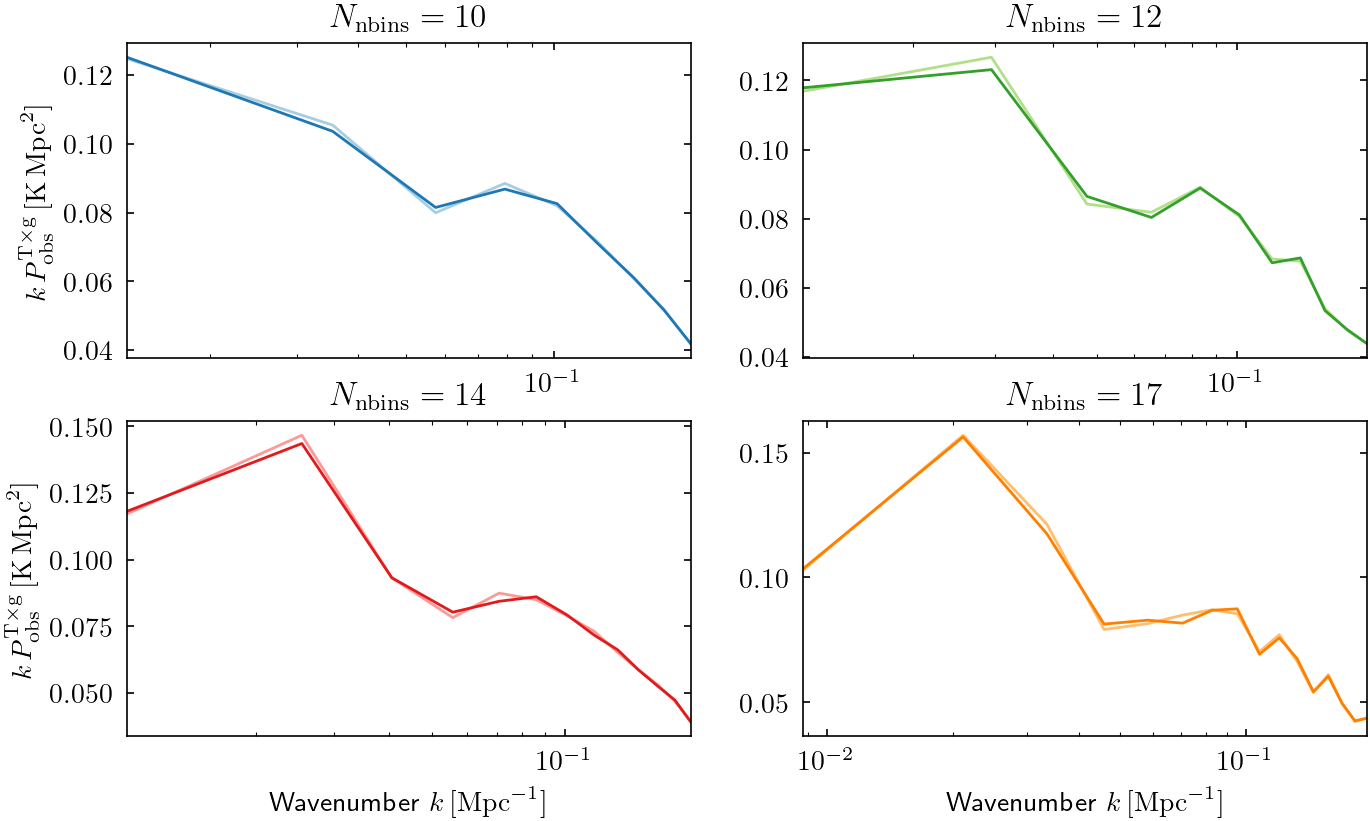

In [14]:
color = iter(Cp)

fw, fh = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(2, 2, figsize=(2*fw, 1.5*fh))

for ax, Nbins in zip(axs.flatten(), [10, 12, 14, 17]):
    k_bins = np.linspace(k[kmask].min(), k[kmask].max(), Nbins)
    print(np.diff(k_bins).mean())
    k_low = 0.5 * (k_bins[1:] + k_bins[:-1])
    N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
    B_low = np.zeros((*bins.shape, *N.shape))
    for i, b in enumerate(bins):
        B_low[i, b - 1] += 1
    B_low *= 1/N

    P_3d_Tgi = Pk_nw_3d_fid_mod[1,...] * T2 * ps.average_hi_temp
    P_3d_Tgi[~kmask] = 0.0
    P_3d_Tgi = get_modelpk_conv(P_3d_Tgi, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P_1d_Tgi = P_3d_Tgi[kmask] @ B_low
    ax.semilogx(k_low, k_low * P_1d_Tgi, c=next(color))

    P_3d_Tgi = Pk_3d_fid_mod[1,...] * T2 * ps.average_hi_temp
    P_3d_Tgi[~kmask] = 0.0
    P_3d_Tgi = get_modelpk_conv(P_3d_Tgi, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)
    P_1d_Tgi = P_3d_Tgi[kmask] @ B_low
    ax.semilogx(k_low, k_low * P_1d_Tgi, c=next(color))

    ax.set_title(r"$N_{{\rm nbins}}={}$".format(Nbins))

axs[0,0].set_ylabel(r"$k\,P^{\rm T \times g}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")
axs[1,0].set_ylabel(r"$k\,P^{\rm T \times g}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")

axs[1,1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
axs[1,0].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")

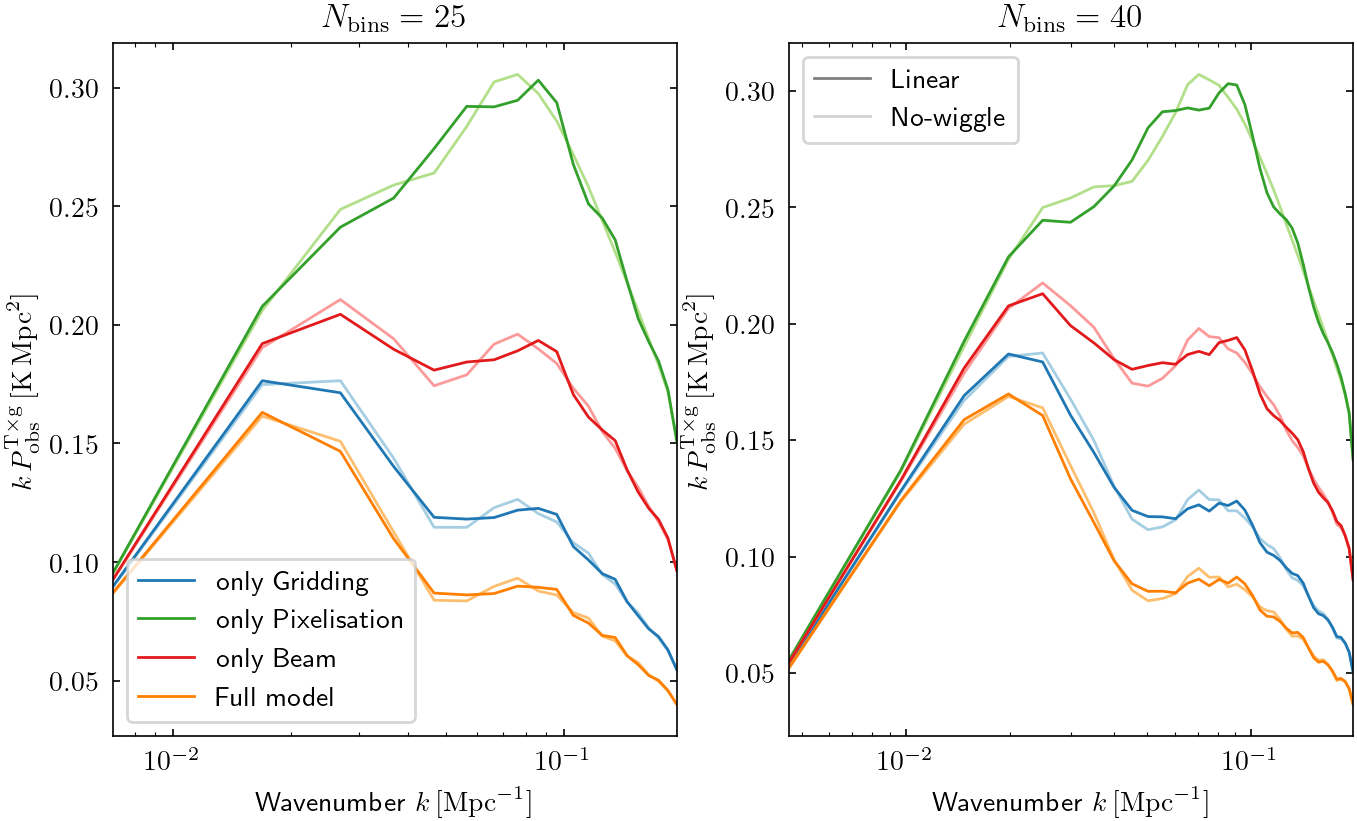

In [ ]:
k_bins = np.linspace(k[kmask].min(), k[kmask].max(), 21)
k_low = 0.5 * (k_bins[1:] + k_bins[:-1])
N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
B_low = np.zeros((*bins.shape, *N.shape))
for i, b in enumerate(bins):
    B_low[i, b - 1] += 1
B_low *= 1/N

k_bins = np.linspace(k[kmask].min(), k[kmask].max(), 40)
k_high = 0.5 * (k_bins[1:] + k_bins[:-1])
N, _, bins = binned_statistic(k[kmask], [], "count", k_bins)
B_high = np.zeros((*bins.shape, *N.shape))
for i, b in enumerate(bins):
    B_high[i, b - 1] += 1
B_high *= 1/N

Ts = [grid**2, pix, beam, T2]
labels = ["only Gridding", "only Pixelisation", "only Beam", "Full model"]

color = iter(Cp)

fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(1, 2, figsize=(2*fw, 1.5*fh))
for T, l  in zip(Ts, labels):
    P_3d_Tgi = Pk_nw_3d_fid_mod[1,...] * T * ps.average_hi_temp
    P_3d_Tgi[~kmask] = 0.0 
    P_3d_Tgi = get_modelpk_conv(P_3d_Tgi, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)

    c = next(color)
    P_1d_Tgi = P_3d_Tgi[kmask] @ B_low
    axs[0].semilogx(k_low, k_low * P_1d_Tgi, c=c)

    P_1d_Tgi = P_3d_Tgi[kmask] @ B_high
    axs[1].semilogx(k_high, k_high * P_1d_Tgi, c=c)

    P_3d_Tgi = Pk_3d_fid_mod[1,...] * T * ps.average_hi_temp
    P_3d_Tgi[~kmask] = 0.0 
    P_3d_Tgi = get_modelpk_conv(P_3d_Tgi, ps.weights_1, ps.weights_field_2 * ps.weights_grid_2)

    c = next(color)
    P_1d_Tgi = P_3d_Tgi[kmask] @ B_low
    axs[0].semilogx(k_low, k_low * P_1d_Tgi, c=c, label=l)

    P_1d_Tgi = P_3d_Tgi[kmask] @ B_high
    axs[1].semilogx(k_high, k_high * P_1d_Tgi, c=c)

axs[0].legend()
for ax in axs:
    ax.set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(r"$k\,P^{\rm T \times g}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")
axs[0].set_title(r"$N_{\rm bins}=25$")
axs[1].set_title(r"$N_{\rm bins}=40$")

axs[1].plot([],[], c="grey", label="Linear")
axs[1].plot([],[], c="lightgrey", label="No-wiggle")
axs[1].legend()

# Taken from Meer21cm

In [12]:
import astropy.units as u

In [13]:
Velg = 892741435.4713972 * u.Mpc**3
Velg

<Quantity 8.92741435e+08 Mpc3>

In [14]:
# ps.survey_volume # 0.6 < z < 1.1
Vmedium = 2741247499.485022 * u.Mpc**3
Vmedium

<Quantity 2.7412475e+09 Mpc3>

In [16]:
# ps.survey_volume
Vfull = 3317226316.455893 * u.Mpc**3
Vfull

<Quantity 3.31722632e+09 Mpc3>